شكل البيانات: (7043, 21)

معلومات البيانات:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16

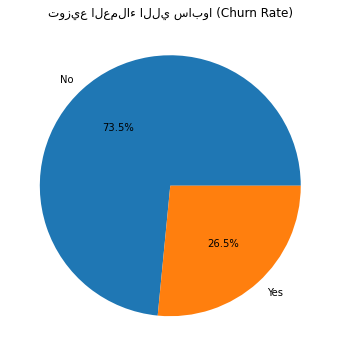

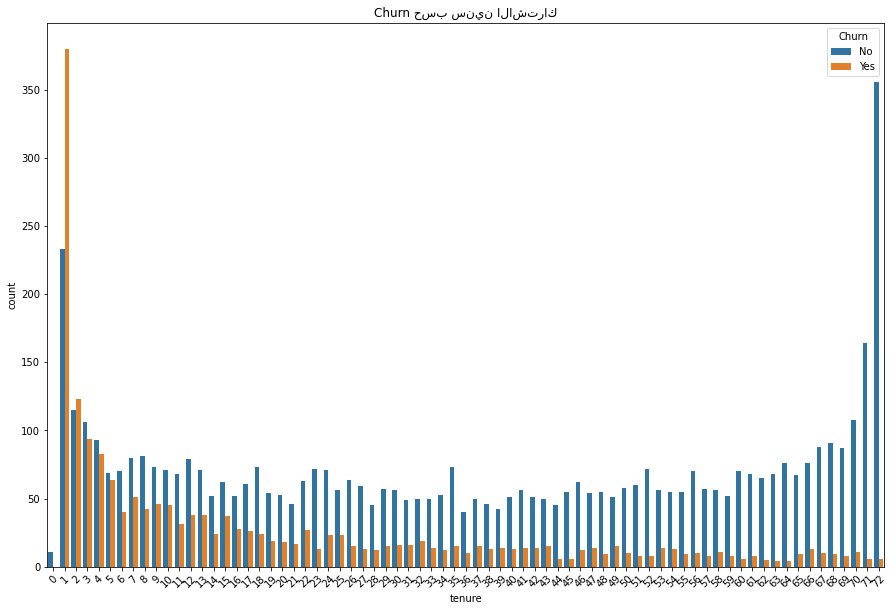

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# تحميل البيانات
df = pd.read_csv('Telco-Customer-Churn.csv')
print("شكل البيانات:", df.shape)
print("\nمعلومات البيانات:")
print(df.info())
print("\nأول 5 صفوف:")
print(df.head())

# إحصائيات سريعة
print("\n📊 الإحصائيات:")
print(df.describe())

# توزيع Churn
plt.figure(figsize=(10,6))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('توزيع العملاء اللي سابوا (Churn Rate)')
plt.ylabel('')
plt.show()

# العلاقة بين المتغيرات الرئيسية
plt.figure(figsize=(15,10))
sns.countplot(data=df, x='tenure', hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn حسب سنين الاشتراك')
plt.show()

In [3]:
# تنظيف ومعالجة
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# تحويل Yes/No لـ 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# One-Hot Encoding للمتغيرات الفئوية
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# تحديد X و y
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']

print("✅ البيانات جاهزة!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nتوزيع Churn:", y.value_counts(normalize=True))

✅ البيانات جاهزة!
X shape: (7032, 23)
y shape: (7032,)

توزيع Churn: Series([], Name: Churn, dtype: float64)


In [27]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# التقسيم
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# النماذج
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'decision tree' : DecisionTreeClassifier(max_depth=10, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# التدريب والتقييم
results = {}
for name, model in models.items():
    if name == 'SVM':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    print(f"{name}: AUC = {auc:.3f}")

# أفضل نموذج
best_model_name = max(results, key=results.get)
print(f"\n🏆 أفضل نموذج: {best_model_name} (AUC: {results[best_model_name]:.3f})")



Logistic Regression: AUC = 0.833
Random Forest: AUC = 0.811
decision tree: AUC = 0.730
SVM: AUC = 0.784

🏆 أفضل نموذج: Logistic Regression (AUC: 0.833)


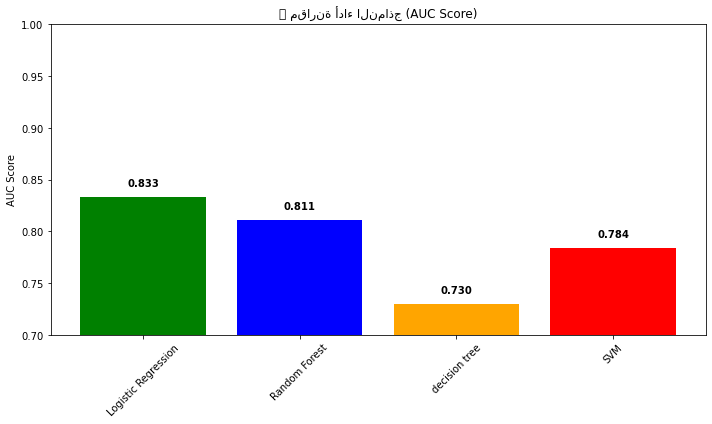

In [28]:
plt.figure(figsize=(10,6))
models_names = list(results.keys())
auc_scores = list(results.values())

bars = plt.bar(models_names, auc_scores, color=['green', 'blue', 'orange','red'])
plt.title('🏆 مقارنة أداء النماذج (AUC Score)')
plt.ylabel('AUC Score')
plt.ylim(0.7, 1.0)

# إضافة القيم على الأشرطة
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




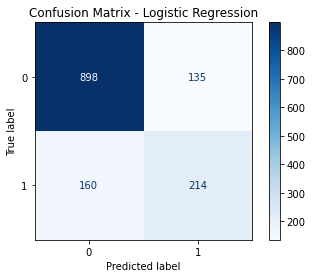

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

In [31]:
import joblib
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump({'columns': X.columns}, 'model_info.pkl')
print("✅ النموذج محفوظ!")

✅ النموذج محفوظ!


In [34]:
def predict_churn(model, customer_data, feature_columns):
    """تنبؤ آمن لأي عميل"""
    import pandas as pd
    import numpy as np
    
    # تحويل لـ DataFrame
    if isinstance(customer_data, dict):
        df = pd.DataFrame([customer_data])
    else:
        df = pd.DataFrame(customer_data)
    
    # إضافة الميزات المفقودة
    for col in feature_columns:
        if col not in df.columns:
            df[col] = 0
    
    # ترتيب نفس الـ columns
    df = df[feature_columns].fillna(0)
    
    # التنبؤ
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]
    
    return pred, prob

# الاستخدام
customer = {
    'tenure': 48,
    'TotalCharges': 1000,
    'MonthlyCharges': 70
}

prediction, probability = predict_churn(best_model, customer, X.columns.tolist())
print(f"النتيجة: {'Churn' if prediction == 1 else 'No Churn'} ({probability:.1%})")

النتيجة: No Churn (13.9%)
